# Tuning hyperparameters

Set directory

In [ ]:
import sys
import os

# Find the project root (Speciale_Kode)
current_dir = os.getcwd()
project_root = current_dir

# Looks for "Speciale_Kode" folder:
while os.path.basename(project_root) != "Speciale_Kode":
    project_root = os.path.dirname(project_root)

# Add to Python path
if project_root not in sys.path:
    sys.path.append(project_root)

Load data:

In [ ]:
from Modules.read_data import read_data
import pandas as pd
from pathlib import Path

(
    DK1_train,
    DK1_test,
    DK2_train,
    DK2_test,
    DK1_train_weather,
    DK1_test_weather,
    DK2_train_weather,
    DK2_test_weather
) = read_data("combined_data_cleaned_v5.csv")
print(f"Features: {DK1_train.columns.tolist()}")

def _load_feature_predictions_for_zone(zone):
    prediction_path = Path(project_root) / "Data" / f"feature_predictions_{zone}_2024-2025.csv"
    if not prediction_path.exists():
        print("No precomputed forecasts found.")
        return None

    predictions = pd.read_csv(prediction_path, decimal=",", parse_dates=["Time"])
    predictions = predictions.loc[:, ~predictions.columns.duplicated()].copy()
    if "DKZone" in predictions.columns:
        predictions = predictions.loc[predictions["DKZone"] == zone].copy()
    return predictions


dk1_feature_predictions = _load_feature_predictions_for_zone("DK1")
dk2_feature_predictions = _load_feature_predictions_for_zone("DK2")
if (dk1_feature_predictions is not None) and (dk2_feature_predictions is not None):
    print("\nPrecomputed forecasts loaded.")

dk1_use_precomputed_feature_values = dk1_feature_predictions is not None
dk2_use_precomputed_feature_values = dk2_feature_predictions is not None

## Choose validation setup


**Setup 1**

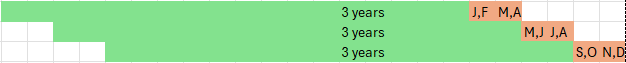

For this setup, val_start in the first fold is fixed at 2024-01-01 00:00:00 and train_end the hour before that (2023-12-31 23:00:00). train_start, val_end and remaining fold values are computed using train_window, predict_horizon and stride.

**Setup 2**



For this setup, val_end in the first fold is fixed at 2024-12-31 23:00:00. train_start, train_end and val_start are computed using train_window and predict_horizon. There is only one fold, so stride has no function.

Write the desired setup number as "split_setup" in the hyper_param_split() function below.

In [ ]:
setup = 2

Import models

In [ ]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
import numpy as np
# Import model library. E.g.:
# from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from Modules.Load_RF_forecast_models import load_rf_models

rf_models = None
if not (dk1_use_precomputed_feature_values and dk2_use_precomputed_feature_values):
    # load_rf_models currently supports only the optional timeout argument.
    rf_models = load_rf_models(user="Christine - laptop")      # set user to "Nikolaj" or "Christine"

# Initialize model:
model = RandomForestRegressor(
    random_state=42,
    n_jobs=-1
)


In [ ]:
from skforecast.exceptions import IgnoredArgumentWarning
import warnings
warnings.filterwarnings("ignore", category=UserWarning, message="Raw feature columns are present")
warnings.filterwarnings("ignore", category=UserWarning, message="Some categorized features not in dataset")
warnings.filterwarnings("ignore", category=UserWarning, message="X does not have valid feature names")
warnings.simplefilter('ignore', category=IgnoredArgumentWarning)

Make train and test periods

In [ ]:
import pandas as pd
from Modules.Validation2 import _build_validation_folds

price_zone = "DK1"
if price_zone == "DK1":
    train_data = DK1_train
    test_data = DK1_test
else:
    train_data = DK2_train
    test_data = DK2_test

dataset = pd.concat([train_data, test_data], ignore_index=True)

folds = _build_validation_folds(
    data=dataset,
    train_window=len(train_data),        
    val_window=len(test_data),
    val_start=str(test_data["Time"].min()),
    predict_period=len(test_data),         # 168 hours = 1 week
    stride=len(test_data),               # stride between predict_periods              
)

train_start = folds[0]["train_start"]
train_end = folds[0]["train_end"]
num_folds = len(folds)
val_start = folds[0]["val_start"]
val_end = val_start + pd.Timedelta(hours=len(test_data) - 1)
prediction_period = folds[0]["val_end"] - folds[0]["val_start"] + pd.Timedelta(hours=1)

print(f"Fold {folds[0]['fold']} train start: {train_start} - train end: {train_end}")
print(f"Number of folds: {num_folds}")
print(f"Test window start: {val_start} - test window end: {val_end}")
print(f"Prediction period: {prediction_period}")
for fold in range(len(folds)):
    print(f"Fold {folds[fold]['fold']} test start: {folds[fold]['val_start']} - test end: {folds[fold]['val_end']}")

# Train and test the final model

## Random Forest

In [ ]:
import pandas as pd
from pathlib import Path
import joblib
from Modules.Validation2 import run_cross_validation
import os
from sklearn.ensemble import RandomForestRegressor

# Initialize model:
model = RandomForestRegressor(
    random_state=42,
    n_jobs=-1
)

# Set price zone and parameters
# ========================
price_zone = "DK1"
retrain_model = True  # Set True only when you want to retrain from scratch
save_model_to_disk = False  # Keep False to avoid multi-GB model files

params = {
    'n_estimators': [200],
    'max_depth': [None],
    'min_samples_split': [2],
    'min_samples_leaf': [1]
}

# =========================

if price_zone == "DK1":
    train_data = DK1_train
    test_data = DK1_test
    feature_predictions = dk1_feature_predictions
    use_precomputed_feature_values = dk1_use_precomputed_feature_values
else:
    train_data = DK2_train
    test_data = DK2_test
    feature_predictions = dk2_feature_predictions
    use_precomputed_feature_values = dk2_use_precomputed_feature_values

dataset = pd.concat([train_data, test_data], ignore_index=True)


results = []


model.set_params(**params)

combination_results = run_cross_validation(
    model=model,
    dataset=dataset,
    dk_zone=price_zone,
    split_setup=2,                          # ignored in Validation2 but safe to keep
    train_window= 2*8760 + 8784,          # full training set
    val_window=len(test_data),     # full test set
    val_start=str(test_data["Time"].min()),
    predict_period=len(test_data), # one fold covering full test period
    stride=len(test_data),
    use_scaler=False,
    print_fold_results=False,
    plot=True,
    rf_models=rf_models,
    use_precomputed_feature_values=use_precomputed_feature_values,
    precomputed_feature_predictions=feature_predictions,
    use_forecasted_history=True
)

# Extract the fitted model
model = combination_results["model"]

fold_results_df = combination_results["fold_results"]
train_start_period = pd.to_datetime(fold_results_df["train_start"]).min()
train_end_period = pd.to_datetime(fold_results_df["train_end"]).max()

row = {
    **params,
    "train_start": train_start_period,
    "train_end": train_end_period,
    "avg_smape": combination_results["overall_avg_weekly_smape"],
    "avg_weekly_rmse": combination_results["overall_avg_weekly_rmse"],
    "avg_weekly_mae": combination_results["overall_avg_weekly_mae"],
    "avg_weekly_smape": combination_results["overall_avg_weekly_smape"],
    "avg_daily_rmse": combination_results["overall_avg_daily_rmse"],
    "avg_daily_mae": combination_results["overall_avg_daily_mae"],
    "avg_daily_smape": combination_results["overall_avg_daily_smape"],
    "avg_smape_day_1": combination_results["avg_smape_day_1"],
    "avg_smape_day_2": combination_results["avg_smape_day_2"],
    "avg_smape_day_3": combination_results["avg_smape_day_3"],
    "avg_smape_day_4": combination_results["avg_smape_day_4"],
    "avg_smape_day_5": combination_results["avg_smape_day_5"],
    "avg_smape_day_6": combination_results["avg_smape_day_6"],
    "avg_smape_day_7": combination_results["avg_smape_day_7"]
}
results.append(row)

# Save metrics
results_df = pd.DataFrame(results).sort_values("avg_smape")
folder = os.path.join(project_root, "Shallow learners")
folder = os.path.join(folder, "Final_eval")
base_filename = f"{price_zone}_RF_final_results.csv"
filename = os.path.join(folder, base_filename)

# adds a number to the filename if a file with same name already exists:
counter = 1
while filename.exists():
    filename = folder / f"{base_filename}_{counter}.csv"
    counter += 1
results_df.to_csv(filename, index=False, decimal=",")

predictions_df = combination_results["predictions"]
predictions_df.to_csv(
    os.path.join(folder, f"{price_zone}_RF_predictions.csv"),
    index=False,
    decimal=","
)

In [ ]:
import pandas as pd
from pathlib import Path
import joblib
from Modules.Validation2 import run_cross_validation
import os
from sklearn.ensemble import RandomForestRegressor

# Initialize model:
model = RandomForestRegressor(
    random_state=42,
    n_jobs=-1
)

# Set price zone and parameters
# ========================
price_zone = "DK2"
retrain_model = True  # Set True only when you want to retrain from scratch
save_model_to_disk = False  # Keep False to avoid multi-GB model files

params = {
    'n_estimators': [50],
    'max_depth': [None],
    'min_samples_split': [2],
    'min_samples_leaf': [10]
}

# =========================

if price_zone == "DK1":
    train_data = DK1_train
    test_data = DK1_test
    feature_predictions = dk1_feature_predictions
    use_precomputed_feature_values = dk1_use_precomputed_feature_values
else:
    train_data = DK2_train
    test_data = DK2_test
    feature_predictions = dk2_feature_predictions
    use_precomputed_feature_values = dk2_use_precomputed_feature_values

dataset = pd.concat([train_data, test_data], ignore_index=True)


results = []


model.set_params(**params)

combination_results = run_cross_validation(
    model=model,
    dataset=dataset,
    dk_zone=price_zone,
    split_setup=2,                          # ignored in Validation2 but safe to keep
    train_window= 2*8760 + 8784,          # full training set
    val_window=len(test_data),     # full test set
    val_start=str(test_data["Time"].min()),
    predict_period=len(test_data), # one fold covering full test period
    stride=len(test_data),
    use_scaler=False,
    print_fold_results=False,
    plot=True,
    rf_models=rf_models,
    use_precomputed_feature_values=use_precomputed_feature_values,
    precomputed_feature_predictions=feature_predictions,
    use_forecasted_history=True
)

# Extract the fitted model
model = combination_results["model"]

fold_results_df = combination_results["fold_results"]
train_start_period = pd.to_datetime(fold_results_df["train_start"]).min()
train_end_period = pd.to_datetime(fold_results_df["train_end"]).max()

row = {
    **params,
    "train_start": train_start_period,
    "train_end": train_end_period,
    "avg_smape": combination_results["overall_avg_weekly_smape"],
    "avg_weekly_rmse": combination_results["overall_avg_weekly_rmse"],
    "avg_weekly_mae": combination_results["overall_avg_weekly_mae"],
    "avg_weekly_smape": combination_results["overall_avg_weekly_smape"],
    "avg_daily_rmse": combination_results["overall_avg_daily_rmse"],
    "avg_daily_mae": combination_results["overall_avg_daily_mae"],
    "avg_daily_smape": combination_results["overall_avg_daily_smape"],
    "avg_smape_day_1": combination_results["avg_smape_day_1"],
    "avg_smape_day_2": combination_results["avg_smape_day_2"],
    "avg_smape_day_3": combination_results["avg_smape_day_3"],
    "avg_smape_day_4": combination_results["avg_smape_day_4"],
    "avg_smape_day_5": combination_results["avg_smape_day_5"],
    "avg_smape_day_6": combination_results["avg_smape_day_6"],
    "avg_smape_day_7": combination_results["avg_smape_day_7"]
}
results.append(row)

# Save metrics
results_df = pd.DataFrame(results).sort_values("avg_smape")
folder = os.path.join(project_root, "Shallow learners")
folder = os.path.join(folder, "Final_eval")
base_filename = f"{price_zone}_RF_final_results.csv"
filename = os.path.join(folder, base_filename)

# adds a number to the filename if a file with same name already exists:
counter = 1
while filename.exists():
    filename = folder / f"{base_filename}_{counter}.csv"
    counter += 1
results_df.to_csv(filename, index=False, decimal=",")

predictions_df = combination_results["predictions"]
predictions_df.to_csv(
    os.path.join(folder, f"{price_zone}_RF_predictions.csv"),
    index=False,
    decimal=","
)

## ARIMA

In [ ]:
import itertools
import os
import warnings

import numpy as np
import pandas as pd
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tools.sm_exceptions import ConvergenceWarning

from Modules.Validation2 import _build_validation_folds, smape

warnings.filterwarnings("ignore", category=ConvergenceWarning)


def _prepare_target_series(data, target_col):
    series = (
        data[["Time", target_col]]
        .copy()
        .sort_values("Time")
        .drop_duplicates(subset="Time")
        .set_index("Time")[target_col]
        .astype(float)
    )
    series.index = pd.DatetimeIndex(series.index)
    return series.asfreq("h")


def _fit_arima(train_series, order):
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", category=ConvergenceWarning)
        fitted_model = ARIMA(
            train_series,
            order=order,
            enforce_stationarity=False,
            enforce_invertibility=False,
        ).fit()
    return fitted_model


def _build_weekly_and_daily_metrics(actual, predicted, fold_no, week_no):
    evaluation = pd.DataFrame(
        {
            "Time": actual.index,
            "Actual": actual.values,
            "Prediction": predicted.reindex(actual.index).values,
        }
    )
    evaluation["Date"] = evaluation["Time"].dt.floor("D")

    rmse = float(np.sqrt(np.mean((evaluation["Actual"] - evaluation["Prediction"]) ** 2)))
    mae = float(np.mean(np.abs(evaluation["Actual"] - evaluation["Prediction"])))
    smape_value = float(smape(evaluation["Actual"].values, evaluation["Prediction"].values))

    weekly_row = {
        "fold": fold_no,
        "week": week_no,
        "week_start": evaluation["Time"].min(),
        "week_end": evaluation["Time"].max(),
        "weekly_rmse": rmse,
        "weekly_mae": mae,
        "weekly_smape": smape_value,
    }

    daily_rows = []
    for date, day_group in evaluation.groupby("Date"):
        daily_rows.append(
            {
                "Date": date,
                "daily_rmse": float(
                    np.sqrt(np.mean((day_group["Actual"] - day_group["Prediction"]) ** 2))
                ),
                "daily_mae": float(np.mean(np.abs(day_group["Actual"] - day_group["Prediction"]))),
                "daily_smape": float(smape(day_group["Actual"].values, day_group["Prediction"].values)),
                "fold": fold_no,
                "week": week_no,
            }
        )

    return weekly_row, pd.DataFrame(daily_rows)


def run_arima_search(
    *,
    price_zone,
    train_data,
    test_data,
    param_grid,
    output_subfolder,
    base_filename,
    train_window,
    val_window,
    val_start,
    predict_period,
    stride,
):
    dataset = pd.concat([train_data, test_data], ignore_index=True)
    dataset = dataset.sort_values("Time").reset_index(drop=True)
    target_col = dataset.columns[0]

    folds = _build_validation_folds(
        data=dataset,
        train_window=train_window,
        val_window=val_window,
        val_start=val_start,
        predict_period=predict_period,
        stride=stride,
    )

    first_fold = folds[0]
    train_mask = (
        (dataset["Time"] >= first_fold["train_start"])
        & (dataset["Time"] <= first_fold["train_end"])
    )
    train_series = _prepare_target_series(dataset.loc[train_mask], target_col)

    param_names = list(param_grid.keys())
    param_values = list(param_grid.values())
    all_combinations = list(itertools.product(*param_values))
    num_combinations = len(all_combinations)

    max_horizon = int(
        (folds[-1]["val_end"] - first_fold["train_end"]).total_seconds() // 3600
    )
    forecast_index = pd.date_range(
        start=first_fold["train_end"] + pd.Timedelta(hours=1),
        periods=max_horizon,
        freq="h",
    )

    print(f"Total number of combinations to test: {num_combinations}")

    results = []
    for comb_number, combination in enumerate(all_combinations, start=1):
        params = dict(zip(param_names, combination))
        order = params["order"]

        print(f"\nCombination {comb_number}/{num_combinations}: {params}")

        try:
            fitted_model = _fit_arima(train_series, order=order)
            forecast = pd.Series(fitted_model.forecast(steps=max_horizon), index=forecast_index)
        except Exception as exc:
            print(f"Combination {comb_number} failed: {exc}")
            continue

        weekly_results = []
        daily_results = []

        for fold in folds:
            fold_mask = (
                (dataset["Time"] >= fold["val_start"])
                & (dataset["Time"] <= fold["val_end"])
            )
            fold_actual = _prepare_target_series(dataset.loc[fold_mask], target_col)
            fold_pred = forecast.loc[fold["val_start"]:fold["val_end"]]

            if len(fold_actual) != len(fold_pred):
                raise ValueError(
                    f"Forecast length mismatch in fold {fold['fold']}: "
                    f"actual={len(fold_actual)}, predicted={len(fold_pred)}"
                )

            fold_week_rmse = []
            fold_week_mae = []
            fold_week_smape = []

            for week_no, start in enumerate(range(0, len(fold_actual), 168), start=1):
                week_actual = fold_actual.iloc[start:start + 168]
                week_pred = fold_pred.iloc[start:start + 168]

                weekly_row, daily_rows = _build_weekly_and_daily_metrics(
                    actual=week_actual,
                    predicted=week_pred,
                    fold_no=fold["fold"],
                    week_no=week_no,
                )
                weekly_results.append(weekly_row)
                daily_results.append(daily_rows)

                fold_week_rmse.append(weekly_row["weekly_rmse"])
                fold_week_mae.append(weekly_row["weekly_mae"])
                fold_week_smape.append(weekly_row["weekly_smape"])

        weekly_results_df = pd.DataFrame(weekly_results)
        daily_results_df = pd.concat(daily_results, ignore_index=True)
        daily_results_df = daily_results_df.sort_values(["fold", "week", "Date"]).reset_index(drop=True)
        daily_results_df["day_in_week"] = daily_results_df.groupby(["fold", "week"]).cumcount() + 1

        overall_daily_rmse_df = (
            daily_results_df.groupby("Date", as_index=False)["daily_rmse"].mean().sort_values("Date")
        )
        overall_daily_mae_df = (
            daily_results_df.groupby("Date", as_index=False)["daily_mae"].mean().sort_values("Date")
        )
        overall_daily_smape_df = (
            daily_results_df.groupby("Date", as_index=False)["daily_smape"].mean().sort_values("Date")
        )

        avg_smape_by_day = {
            f"avg_smape_day_{day}": daily_results_df.loc[
                daily_results_df["day_in_week"] == day,
                "daily_smape",
            ].mean()
            for day in range(1, 8)
        }

        row = {
            **params,
            "avg_smape": weekly_results_df["weekly_smape"].mean(),
            "avg_weekly_rmse": weekly_results_df["weekly_rmse"].mean(),
            "avg_weekly_mae": weekly_results_df["weekly_mae"].mean(),
            "avg_weekly_smape": weekly_results_df["weekly_smape"].mean(),
            "avg_daily_rmse": overall_daily_rmse_df["daily_rmse"].mean(),
            "avg_daily_mae": overall_daily_mae_df["daily_mae"].mean(),
            "avg_daily_smape": overall_daily_smape_df["daily_smape"].mean(),
            **avg_smape_by_day,
        }
        results.append(row)

    results_df = pd.DataFrame(results).sort_values("avg_smape")

    folder = os.path.join(project_root, "Shallow learners", output_subfolder)
    os.makedirs(folder, exist_ok=True)
    filename = os.path.join(folder, f"{base_filename}.csv")

    counter = 1
    while os.path.exists(filename):
        filename = os.path.join(folder, f"{base_filename}_{counter}.csv")
        counter += 1

    results_df.to_csv(filename, index=False, decimal=",")
    print(f"\nResults saved to: {filename}")

    return results_df, filename


In [ ]:
import os
import pandas as pd

price_zone = "DK1"
final_order = (2, 1, 1)

if price_zone == "DK1":
    train_data = DK1_train
    test_data = DK1_test
else:
    train_data = DK2_train
    test_data = DK2_test

train_series = _prepare_target_series(train_data, train_data.columns[0])
test_series = _prepare_target_series(test_data, test_data.columns[0])

fitted_model = _fit_arima(train_series, final_order)
forecast = pd.Series(
    fitted_model.forecast(steps=len(test_series)),
    index=test_series.index,
)

evaluation = pd.DataFrame(
    {
        "Time": test_series.index,
        "Actual": test_series.values,
        "Prediction": forecast.values,
    }
)
evaluation["Date"] = evaluation["Time"].dt.floor("D")

weekly_rows = []
daily_rows = []
for week_no, start in enumerate(range(0, len(evaluation), 168), start=1):
    week_eval = evaluation.iloc[start:start + 168].copy()

    weekly_rows.append(
        {
            "fold": 1,
            "week": week_no,
            "week_start": week_eval["Time"].min(),
            "week_end": week_eval["Time"].max(),
            "weekly_rmse": float(np.sqrt(np.mean((week_eval["Actual"] - week_eval["Prediction"]) ** 2))),
            "weekly_mae": float(np.mean(np.abs(week_eval["Actual"] - week_eval["Prediction"]))),
            "weekly_smape": float(smape(week_eval["Actual"].values, week_eval["Prediction"].values)),
        }
    )

    for date, day_group in week_eval.groupby("Date"):
        daily_rows.append(
            {
                "fold": 1,
                "week": week_no,
                "Date": date,
                "daily_rmse": float(np.sqrt(np.mean((day_group["Actual"] - day_group["Prediction"]) ** 2))),
                "daily_mae": float(np.mean(np.abs(day_group["Actual"] - day_group["Prediction"]))),
                "daily_smape": float(smape(day_group["Actual"].values, day_group["Prediction"].values)),
            }
        )

weekly_results_df = pd.DataFrame(weekly_rows)
daily_results_df = pd.DataFrame(daily_rows).sort_values(["fold", "week", "Date"]).reset_index(drop=True)
daily_results_df["day_in_week"] = daily_results_df.groupby(["fold", "week"]).cumcount() + 1

overall_daily_rmse_df = (
    daily_results_df.groupby("Date", as_index=False)["daily_rmse"].mean().sort_values("Date")
)
overall_daily_mae_df = (
    daily_results_df.groupby("Date", as_index=False)["daily_mae"].mean().sort_values("Date")
)
overall_daily_smape_df = (
    daily_results_df.groupby("Date", as_index=False)["daily_smape"].mean().sort_values("Date")
)

avg_smape_by_day = {
    f"avg_smape_day_{day}": daily_results_df.loc[
        daily_results_df["day_in_week"] == day,
        "daily_smape",
    ].mean()
    for day in range(1, 8)
}

results_df = pd.DataFrame(
    [
        {
            "order": final_order,
            "avg_smape": weekly_results_df["weekly_smape"].mean(),
            "avg_weekly_rmse": weekly_results_df["weekly_rmse"].mean(),
            "avg_weekly_mae": weekly_results_df["weekly_mae"].mean(),
            "avg_weekly_smape": weekly_results_df["weekly_smape"].mean(),
            "avg_daily_rmse": overall_daily_rmse_df["daily_rmse"].mean(),
            "avg_daily_mae": overall_daily_mae_df["daily_mae"].mean(),
            "avg_daily_smape": overall_daily_smape_df["daily_smape"].mean(),
            **avg_smape_by_day,
        }
    ]
)

folder = os.path.join(project_root, "Shallow learners")
folder = os.path.join(folder, "Final_eval")
os.makedirs(folder, exist_ok=True)
base_filename = f"{price_zone}_final_ARIMA_results"
filename = os.path.join(folder, f"{base_filename}.csv")

counter = 1
while os.path.exists(filename):
    filename = os.path.join(folder, f"{base_filename}_{counter}.csv")
    counter += 1

results_df.to_csv(filename, index=False, decimal=",")

print(f"\nResults saved to: {filename}")

evaluation.to_csv(
    os.path.join(folder, f"{price_zone}_ARIMA_predictions.csv"),
    index=False,
    decimal=","
)

In [ ]:
import os
import pandas as pd

price_zone = "DK2"
final_order = (2, 1, 1)

if price_zone == "DK1":
    train_data = DK1_train
    test_data = DK1_test
else:
    train_data = DK2_train
    test_data = DK2_test

train_series = _prepare_target_series(train_data, train_data.columns[0])
test_series = _prepare_target_series(test_data, test_data.columns[0])

fitted_model = _fit_arima(train_series, final_order)
forecast = pd.Series(
    fitted_model.forecast(steps=len(test_series)),
    index=test_series.index,
)

evaluation = pd.DataFrame(
    {
        "Time": test_series.index,
        "Actual": test_series.values,
        "Prediction": forecast.values,
    }
)
evaluation["Date"] = evaluation["Time"].dt.floor("D")

weekly_rows = []
daily_rows = []
for week_no, start in enumerate(range(0, len(evaluation), 168), start=1):
    week_eval = evaluation.iloc[start:start + 168].copy()

    weekly_rows.append(
        {
            "fold": 1,
            "week": week_no,
            "week_start": week_eval["Time"].min(),
            "week_end": week_eval["Time"].max(),
            "weekly_rmse": float(np.sqrt(np.mean((week_eval["Actual"] - week_eval["Prediction"]) ** 2))),
            "weekly_mae": float(np.mean(np.abs(week_eval["Actual"] - week_eval["Prediction"]))),
            "weekly_smape": float(smape(week_eval["Actual"].values, week_eval["Prediction"].values)),
        }
    )

    for date, day_group in week_eval.groupby("Date"):
        daily_rows.append(
            {
                "fold": 1,
                "week": week_no,
                "Date": date,
                "daily_rmse": float(np.sqrt(np.mean((day_group["Actual"] - day_group["Prediction"]) ** 2))),
                "daily_mae": float(np.mean(np.abs(day_group["Actual"] - day_group["Prediction"]))),
                "daily_smape": float(smape(day_group["Actual"].values, day_group["Prediction"].values)),
            }
        )

weekly_results_df = pd.DataFrame(weekly_rows)
daily_results_df = pd.DataFrame(daily_rows).sort_values(["fold", "week", "Date"]).reset_index(drop=True)
daily_results_df["day_in_week"] = daily_results_df.groupby(["fold", "week"]).cumcount() + 1

overall_daily_rmse_df = (
    daily_results_df.groupby("Date", as_index=False)["daily_rmse"].mean().sort_values("Date")
)
overall_daily_mae_df = (
    daily_results_df.groupby("Date", as_index=False)["daily_mae"].mean().sort_values("Date")
)
overall_daily_smape_df = (
    daily_results_df.groupby("Date", as_index=False)["daily_smape"].mean().sort_values("Date")
)

avg_smape_by_day = {
    f"avg_smape_day_{day}": daily_results_df.loc[
        daily_results_df["day_in_week"] == day,
        "daily_smape",
    ].mean()
    for day in range(1, 8)
}

results_df = pd.DataFrame(
    [
        {
            "order": final_order,
            "avg_smape": weekly_results_df["weekly_smape"].mean(),
            "avg_weekly_rmse": weekly_results_df["weekly_rmse"].mean(),
            "avg_weekly_mae": weekly_results_df["weekly_mae"].mean(),
            "avg_weekly_smape": weekly_results_df["weekly_smape"].mean(),
            "avg_daily_rmse": overall_daily_rmse_df["daily_rmse"].mean(),
            "avg_daily_mae": overall_daily_mae_df["daily_mae"].mean(),
            "avg_daily_smape": overall_daily_smape_df["daily_smape"].mean(),
            **avg_smape_by_day,
        }
    ]
)

folder = os.path.join(project_root, "Shallow learners")
folder = os.path.join(folder, "Final_eval")
os.makedirs(folder, exist_ok=True)
base_filename = f"{price_zone}_final_ARIMA_results"
filename = os.path.join(folder, f"{base_filename}.csv")

counter = 1
while os.path.exists(filename):
    filename = os.path.join(folder, f"{base_filename}_{counter}.csv")
    counter += 1

results_df.to_csv(filename, index=False, decimal=",")

print(f"\nResults saved to: {filename}")

evaluation.to_csv(
    os.path.join(folder, f"{price_zone}_ARIMA_predictions.csv"),
    index=False,
    decimal=","
)

## LightGBM

In [ ]:
import pandas as pd
from pathlib import Path
import joblib
from Modules.Validation2 import run_cross_validation
import os
from lightgbm import LGBMRegressor

# Initialize model:
model = LGBMRegressor(
    objective="regression",
    random_state=42,
    n_jobs=-1
)

# Set price zone and parameters
# ========================
price_zone = "DK1"
retrain_model = True  # Set True only when you want to retrain from scratch
save_model_to_disk = False  # Keep False to avoid multi-GB model files

params = {
    "n_estimators": [200],
    "learning_rate": [0.01],
    "num_leaves": [15],            
    "max_depth": [-1],
    "min_child_samples": [1],
    "subsample": [0.8],
    "subsample_freq": [1],
    "colsample_bytree": [1.0],
    "reg_alpha": [0.0],
    "reg_lambda": [0.0]
}

# =========================

if price_zone == "DK1":
    train_data = DK1_train
    test_data = DK1_test
    feature_predictions = dk1_feature_predictions
    use_precomputed_feature_values = dk1_use_precomputed_feature_values
else:
    train_data = DK2_train
    test_data = DK2_test
    feature_predictions = dk2_feature_predictions
    use_precomputed_feature_values = dk2_use_precomputed_feature_values

dataset = pd.concat([train_data, test_data], ignore_index=True)


results = []


model.set_params(**params)

combination_results = run_cross_validation(
    model=model,
    dataset=dataset,
    dk_zone=price_zone,
    split_setup=2,                          # ignored in Validation2 but safe to keep
    train_window= 2*8760 + 8784,          # full training set
    val_window=len(test_data),     # full test set
    val_start=str(test_data["Time"].min()),
    predict_period=len(test_data), # one fold covering full test period
    stride=len(test_data),
    use_scaler=False,
    print_fold_results=False,
    plot=True,
    rf_models=rf_models,
    use_precomputed_feature_values=use_precomputed_feature_values,
    precomputed_feature_predictions=feature_predictions,
    use_forecasted_history=True
)

# Extract the fitted model
model = combination_results["model"]

fold_results_df = combination_results["fold_results"]
train_start_period = pd.to_datetime(fold_results_df["train_start"]).min()
train_end_period = pd.to_datetime(fold_results_df["train_end"]).max()

row = {
    **params,
    "train_start": train_start_period,
    "train_end": train_end_period,
    "avg_smape": combination_results["overall_avg_weekly_smape"],
    "avg_weekly_rmse": combination_results["overall_avg_weekly_rmse"],
    "avg_weekly_mae": combination_results["overall_avg_weekly_mae"],
    "avg_weekly_smape": combination_results["overall_avg_weekly_smape"],
    "avg_daily_rmse": combination_results["overall_avg_daily_rmse"],
    "avg_daily_mae": combination_results["overall_avg_daily_mae"],
    "avg_daily_smape": combination_results["overall_avg_daily_smape"],
    "avg_smape_day_1": combination_results["avg_smape_day_1"],
    "avg_smape_day_2": combination_results["avg_smape_day_2"],
    "avg_smape_day_3": combination_results["avg_smape_day_3"],
    "avg_smape_day_4": combination_results["avg_smape_day_4"],
    "avg_smape_day_5": combination_results["avg_smape_day_5"],
    "avg_smape_day_6": combination_results["avg_smape_day_6"],
    "avg_smape_day_7": combination_results["avg_smape_day_7"]
}
results.append(row)

# Save metrics
results_df = pd.DataFrame(results).sort_values("avg_smape")
folder = os.path.join(project_root, "Shallow learners")
folder = os.path.join(folder, "Final_eval")
base_filename = f"{price_zone}_LightGBM_final_results.csv"
filename = os.path.join(folder, base_filename)

# adds a number to the filename if a file with same name already exists:
counter = 1
while filename.exists():
    filename = folder / f"{base_filename}_{counter}.csv"
    counter += 1
results_df.to_csv(filename, index=False, decimal=",")

predictions_df = combination_results["predictions"]
predictions_df.to_csv(
    os.path.join(folder, f"{price_zone}_LightGBM_predictions.csv"),
    index=False,
    decimal=","
)

In [ ]:
import pandas as pd
from pathlib import Path
import joblib
from Modules.Validation2 import run_cross_validation
import os
from lightgbm import LGBMRegressor

# Initialize model:
model = LGBMRegressor(
    objective="regression",
    random_state=42,
    n_jobs=-1
)

# Set price zone and parameters
# ========================
price_zone = "DK2"
retrain_model = True  # Set True only when you want to retrain from scratch
save_model_to_disk = False  # Keep False to avoid multi-GB model files

params = {
    "n_estimators": [200],
    "learning_rate": [0.01],
    "num_leaves": [127],            
    "max_depth": [-1],
    "min_child_samples": [50],
    "subsample": [0.8],
    "subsample_freq": [1],
    "colsample_bytree": [1.0],
    "reg_alpha": [0.0],
    "reg_lambda": [0.0]
}

# =========================

if price_zone == "DK1":
    train_data = DK1_train
    test_data = DK1_test
    feature_predictions = dk1_feature_predictions
    use_precomputed_feature_values = dk1_use_precomputed_feature_values
else:
    train_data = DK2_train
    test_data = DK2_test
    feature_predictions = dk2_feature_predictions
    use_precomputed_feature_values = dk2_use_precomputed_feature_values

dataset = pd.concat([train_data, test_data], ignore_index=True)


results = []


model.set_params(**params)

combination_results = run_cross_validation(
    model=model,
    dataset=dataset,
    dk_zone=price_zone,
    split_setup=2,                          # ignored in Validation2 but safe to keep
    train_window= 2*8760 + 8784,          # full training set
    val_window=len(test_data),     # full test set
    val_start=str(test_data["Time"].min()),
    predict_period=len(test_data), # one fold covering full test period
    stride=len(test_data),
    use_scaler=False,
    print_fold_results=False,
    plot=True,
    rf_models=rf_models,
    use_precomputed_feature_values=use_precomputed_feature_values,
    precomputed_feature_predictions=feature_predictions,
    use_forecasted_history=True
)

# Extract the fitted model
model = combination_results["model"]

fold_results_df = combination_results["fold_results"]
train_start_period = pd.to_datetime(fold_results_df["train_start"]).min()
train_end_period = pd.to_datetime(fold_results_df["train_end"]).max()

row = {
    **params,
    "train_start": train_start_period,
    "train_end": train_end_period,
    "avg_smape": combination_results["overall_avg_weekly_smape"],
    "avg_weekly_rmse": combination_results["overall_avg_weekly_rmse"],
    "avg_weekly_mae": combination_results["overall_avg_weekly_mae"],
    "avg_weekly_smape": combination_results["overall_avg_weekly_smape"],
    "avg_daily_rmse": combination_results["overall_avg_daily_rmse"],
    "avg_daily_mae": combination_results["overall_avg_daily_mae"],
    "avg_daily_smape": combination_results["overall_avg_daily_smape"],
    "avg_smape_day_1": combination_results["avg_smape_day_1"],
    "avg_smape_day_2": combination_results["avg_smape_day_2"],
    "avg_smape_day_3": combination_results["avg_smape_day_3"],
    "avg_smape_day_4": combination_results["avg_smape_day_4"],
    "avg_smape_day_5": combination_results["avg_smape_day_5"],
    "avg_smape_day_6": combination_results["avg_smape_day_6"],
    "avg_smape_day_7": combination_results["avg_smape_day_7"]
}
results.append(row)

# Save metrics
results_df = pd.DataFrame(results).sort_values("avg_smape")
folder = os.path.join(project_root, "Shallow learners")
folder = os.path.join(folder, "Final_eval")
base_filename = f"{price_zone}_LightGBM_final_results.csv"
filename = os.path.join(folder, base_filename)

# adds a number to the filename if a file with same name already exists:
counter = 1
while filename.exists():
    filename = folder / f"{base_filename}_{counter}.csv"
    counter += 1
results_df.to_csv(filename, index=False, decimal=",")

predictions_df = combination_results["predictions"]
predictions_df.to_csv(
    os.path.join(folder, f"{price_zone}_LightGBM_predictions.csv"),
    index=False,
    decimal=","
)

## Linear Regression

In [ ]:
import pandas as pd
from pathlib import Path
import joblib
from Modules.Validation2 import run_cross_validation
import os
from sklearn.linear_model import LinearRegression, Ridge, Lasso

# Initialize model:
model = Lasso(max_iter=5000)

# Set price zone and parameters
# ========================
price_zone = "DK1"
retrain_model = True  # Set True only when you want to retrain from scratch
save_model_to_disk = False  # Keep False to avoid multi-GB model files

params = {
    'alpha': [0.0001]
}

# =========================

if price_zone == "DK1":
    train_data = DK1_train
    test_data = DK1_test
    feature_predictions = dk1_feature_predictions
    use_precomputed_feature_values = dk1_use_precomputed_feature_values
else:
    train_data = DK2_train
    test_data = DK2_test
    feature_predictions = dk2_feature_predictions
    use_precomputed_feature_values = dk2_use_precomputed_feature_values

dataset = pd.concat([train_data, test_data], ignore_index=True)


results = []


model.set_params(**params)

combination_results = run_cross_validation(
    model=model,
    dataset=dataset,
    dk_zone=price_zone,
    split_setup=2,                          # ignored in Validation2 but safe to keep
    train_window= 2*8760 + 8784,          # full training set
    val_window=len(test_data),     # full test set
    val_start=str(test_data["Time"].min()),
    predict_period=len(test_data), # one fold covering full test period
    stride=len(test_data),
    use_scaler=False,
    print_fold_results=False,
    plot=True,
    rf_models=rf_models,
    use_precomputed_feature_values=use_precomputed_feature_values,
    precomputed_feature_predictions=feature_predictions,
    use_forecasted_history=True
)

# Extract the fitted model
model = combination_results["model"]

fold_results_df = combination_results["fold_results"]
train_start_period = pd.to_datetime(fold_results_df["train_start"]).min()
train_end_period = pd.to_datetime(fold_results_df["train_end"]).max()

row = {
    **params,
    "train_start": train_start_period,
    "train_end": train_end_period,
    "avg_smape": combination_results["overall_avg_weekly_smape"],
    "avg_weekly_rmse": combination_results["overall_avg_weekly_rmse"],
    "avg_weekly_mae": combination_results["overall_avg_weekly_mae"],
    "avg_weekly_smape": combination_results["overall_avg_weekly_smape"],
    "avg_daily_rmse": combination_results["overall_avg_daily_rmse"],
    "avg_daily_mae": combination_results["overall_avg_daily_mae"],
    "avg_daily_smape": combination_results["overall_avg_daily_smape"],
    "avg_smape_day_1": combination_results["avg_smape_day_1"],
    "avg_smape_day_2": combination_results["avg_smape_day_2"],
    "avg_smape_day_3": combination_results["avg_smape_day_3"],
    "avg_smape_day_4": combination_results["avg_smape_day_4"],
    "avg_smape_day_5": combination_results["avg_smape_day_5"],
    "avg_smape_day_6": combination_results["avg_smape_day_6"],
    "avg_smape_day_7": combination_results["avg_smape_day_7"]
}
results.append(row)

# Save metrics
results_df = pd.DataFrame(results).sort_values("avg_smape")
folder = os.path.join(project_root, "Shallow learners")
folder = os.path.join(folder, "Final_eval")
base_filename = f"{price_zone}_Lasso_final_results.csv"
filename = os.path.join(folder, base_filename)

# adds a number to the filename if a file with same name already exists:
counter = 1
while filename.exists():
    filename = folder / f"{base_filename}_{counter}.csv"
    counter += 1
results_df.to_csv(filename, index=False, decimal=",")

predictions_df = combination_results["predictions"]
predictions_df.to_csv(
    os.path.join(folder, f"{price_zone}_Lasso_predictions.csv"),
    index=False,
    decimal=","
)

In [ ]:
import pandas as pd
from pathlib import Path
import joblib
from Modules.Validation2 import run_cross_validation
import os
from sklearn.linear_model import LinearRegression, Ridge, Lasso

# Initialize model:
model = Lasso(max_iter=5000)

# Set price zone and parameters
# ========================
price_zone = "DK2"
retrain_model = True  # Set True only when you want to retrain from scratch
save_model_to_disk = False  # Keep False to avoid multi-GB model files

params = {
    'alpha': [50]
}

# =========================

if price_zone == "DK1":
    train_data = DK1_train
    test_data = DK1_test
    feature_predictions = dk1_feature_predictions
    use_precomputed_feature_values = dk1_use_precomputed_feature_values
else:
    train_data = DK2_train
    test_data = DK2_test
    feature_predictions = dk2_feature_predictions
    use_precomputed_feature_values = dk2_use_precomputed_feature_values

dataset = pd.concat([train_data, test_data], ignore_index=True)


results = []


model.set_params(**params)

combination_results = run_cross_validation(
    model=model,
    dataset=dataset,
    dk_zone=price_zone,
    split_setup=2,                          # ignored in Validation2 but safe to keep
    train_window= 2*8760 + 8784,          # full training set
    val_window=len(test_data),     # full test set
    val_start=str(test_data["Time"].min()),
    predict_period=len(test_data), # one fold covering full test period
    stride=len(test_data),
    use_scaler=False,
    print_fold_results=False,
    plot=True,
    rf_models=rf_models,
    use_precomputed_feature_values=use_precomputed_feature_values,
    precomputed_feature_predictions=feature_predictions,
    use_forecasted_history=True
)

# Extract the fitted model
model = combination_results["model"]

fold_results_df = combination_results["fold_results"]
train_start_period = pd.to_datetime(fold_results_df["train_start"]).min()
train_end_period = pd.to_datetime(fold_results_df["train_end"]).max()

row = {
    **params,
    "train_start": train_start_period,
    "train_end": train_end_period,
    "avg_smape": combination_results["overall_avg_weekly_smape"],
    "avg_weekly_rmse": combination_results["overall_avg_weekly_rmse"],
    "avg_weekly_mae": combination_results["overall_avg_weekly_mae"],
    "avg_weekly_smape": combination_results["overall_avg_weekly_smape"],
    "avg_daily_rmse": combination_results["overall_avg_daily_rmse"],
    "avg_daily_mae": combination_results["overall_avg_daily_mae"],
    "avg_daily_smape": combination_results["overall_avg_daily_smape"],
    "avg_smape_day_1": combination_results["avg_smape_day_1"],
    "avg_smape_day_2": combination_results["avg_smape_day_2"],
    "avg_smape_day_3": combination_results["avg_smape_day_3"],
    "avg_smape_day_4": combination_results["avg_smape_day_4"],
    "avg_smape_day_5": combination_results["avg_smape_day_5"],
    "avg_smape_day_6": combination_results["avg_smape_day_6"],
    "avg_smape_day_7": combination_results["avg_smape_day_7"]
}
results.append(row)

# Save metrics
results_df = pd.DataFrame(results).sort_values("avg_smape")
folder = os.path.join(project_root, "Shallow learners")
folder = os.path.join(folder, "Final_eval")
base_filename = f"{price_zone}_Lasso_final_results.csv"
filename = os.path.join(folder, base_filename)

# adds a number to the filename if a file with same name already exists:
counter = 1
while filename.exists():
    filename = folder / f"{base_filename}_{counter}.csv"
    counter += 1
results_df.to_csv(filename, index=False, decimal=",")

predictions_df = combination_results["predictions"]
predictions_df.to_csv(
    os.path.join(folder, f"{price_zone}_Lasso_predictions.csv"),
    index=False,
    decimal=","
)

## Support Vector Regression

In [ ]:
import pandas as pd
from pathlib import Path
import joblib
from Modules.Validation2 import run_cross_validation
import os
from sklearn.svm import SVR

# Initialize model:
model = SVR()

# Set price zone and parameters
# ========================
price_zone = "DK1"
retrain_model = True  # Set True only when you want to retrain from scratch
save_model_to_disk = False  # Keep False to avoid multi-GB model files

params = {
    "kernel": "poly",
    "C": 0.1,
    "gamma": "auto",
    "epsilon": 0.1,
    "degree": 2,
}

# =========================

if price_zone == "DK1":
    train_data = DK1_train
    test_data = DK1_test
    feature_predictions = dk1_feature_predictions
    use_precomputed_feature_values = dk1_use_precomputed_feature_values
else:
    train_data = DK2_train
    test_data = DK2_test
    feature_predictions = dk2_feature_predictions
    use_precomputed_feature_values = dk2_use_precomputed_feature_values

dataset = pd.concat([train_data, test_data], ignore_index=True)


results = []


model.set_params(**params)

combination_results = run_cross_validation(
    model=model,
    dataset=dataset,
    dk_zone=price_zone,
    split_setup=2,                          # ignored in Validation2 but safe to keep
    train_window= 2*8760 + 8784,          # full training set
    val_window=len(test_data),     # full test set
    val_start=str(test_data["Time"].min()),
    predict_period=len(test_data), # one fold covering full test period
    stride=len(test_data),
    use_scaler=False,
    print_fold_results=False,
    plot=True,
    rf_models=rf_models,
    use_precomputed_feature_values=use_precomputed_feature_values,
    precomputed_feature_predictions=feature_predictions,
    use_forecasted_history=True
)

# Extract the fitted model
model = combination_results["model"]

fold_results_df = combination_results["fold_results"]
train_start_period = pd.to_datetime(fold_results_df["train_start"]).min()
train_end_period = pd.to_datetime(fold_results_df["train_end"]).max()

row = {
    **params,
    "train_start": train_start_period,
    "train_end": train_end_period,
    "avg_smape": combination_results["overall_avg_weekly_smape"],
    "avg_weekly_rmse": combination_results["overall_avg_weekly_rmse"],
    "avg_weekly_mae": combination_results["overall_avg_weekly_mae"],
    "avg_weekly_smape": combination_results["overall_avg_weekly_smape"],
    "avg_daily_rmse": combination_results["overall_avg_daily_rmse"],
    "avg_daily_mae": combination_results["overall_avg_daily_mae"],
    "avg_daily_smape": combination_results["overall_avg_daily_smape"],
    "avg_smape_day_1": combination_results["avg_smape_day_1"],
    "avg_smape_day_2": combination_results["avg_smape_day_2"],
    "avg_smape_day_3": combination_results["avg_smape_day_3"],
    "avg_smape_day_4": combination_results["avg_smape_day_4"],
    "avg_smape_day_5": combination_results["avg_smape_day_5"],
    "avg_smape_day_6": combination_results["avg_smape_day_6"],
    "avg_smape_day_7": combination_results["avg_smape_day_7"]
}
results.append(row)

# Save metrics
results_df = pd.DataFrame(results).sort_values("avg_smape")
folder = os.path.join(project_root, "Shallow learners")
folder = os.path.join(folder, "Final_eval")
base_filename = f"{price_zone}_SVR_final_results.csv"
filename = os.path.join(folder, base_filename)

# adds a number to the filename if a file with same name already exists:
counter = 1
while filename.exists():
    filename = folder / f"{base_filename}_{counter}.csv"
    counter += 1
results_df.to_csv(filename, index=False, decimal=",")

predictions_df = combination_results["predictions"]
predictions_df.to_csv(
    os.path.join(folder, f"{price_zone}_SVR_predictions.csv"),
    index=False,
    decimal=","
)

In [ ]:
import pandas as pd
from pathlib import Path
import joblib
from Modules.Validation2 import run_cross_validation
import os
from sklearn.svm import SVR

# Initialize model:
model = SVR()

# Set price zone and parameters
# ========================
price_zone = "DK2"
retrain_model = True  # Set True only when you want to retrain from scratch
save_model_to_disk = False  # Keep False to avoid multi-GB model files

params = {
    "kernel": "rbf",
    "C": 1.0,
    "gamma": "auto",
    "epsilon": 0.5,
}
# =========================

if price_zone == "DK1":
    train_data = DK1_train
    test_data = DK1_test
    feature_predictions = dk1_feature_predictions
    use_precomputed_feature_values = dk1_use_precomputed_feature_values
else:
    train_data = DK2_train
    test_data = DK2_test
    feature_predictions = dk2_feature_predictions
    use_precomputed_feature_values = dk2_use_precomputed_feature_values

dataset = pd.concat([train_data, test_data], ignore_index=True)


results = []


model.set_params(**params)

combination_results = run_cross_validation(
    model=model,
    dataset=dataset,
    dk_zone=price_zone,
    split_setup=2,                          # ignored in Validation2 but safe to keep
    train_window= 2*8760 + 8784,          # full training set
    val_window=len(test_data),     # full test set
    val_start=str(test_data["Time"].min()),
    predict_period=len(test_data), # one fold covering full test period
    stride=len(test_data),
    use_scaler=False,
    print_fold_results=False,
    plot=True,
    rf_models=rf_models,
    use_precomputed_feature_values=use_precomputed_feature_values,
    precomputed_feature_predictions=feature_predictions,
    use_forecasted_history=True
)

# Extract the fitted model
model = combination_results["model"]

fold_results_df = combination_results["fold_results"]
train_start_period = pd.to_datetime(fold_results_df["train_start"]).min()
train_end_period = pd.to_datetime(fold_results_df["train_end"]).max()

row = {
    **params,
    "train_start": train_start_period,
    "train_end": train_end_period,
    "avg_smape": combination_results["overall_avg_weekly_smape"],
    "avg_weekly_rmse": combination_results["overall_avg_weekly_rmse"],
    "avg_weekly_mae": combination_results["overall_avg_weekly_mae"],
    "avg_weekly_smape": combination_results["overall_avg_weekly_smape"],
    "avg_daily_rmse": combination_results["overall_avg_daily_rmse"],
    "avg_daily_mae": combination_results["overall_avg_daily_mae"],
    "avg_daily_smape": combination_results["overall_avg_daily_smape"],
    "avg_smape_day_1": combination_results["avg_smape_day_1"],
    "avg_smape_day_2": combination_results["avg_smape_day_2"],
    "avg_smape_day_3": combination_results["avg_smape_day_3"],
    "avg_smape_day_4": combination_results["avg_smape_day_4"],
    "avg_smape_day_5": combination_results["avg_smape_day_5"],
    "avg_smape_day_6": combination_results["avg_smape_day_6"],
    "avg_smape_day_7": combination_results["avg_smape_day_7"]
}
results.append(row)

# Save metrics
results_df = pd.DataFrame(results).sort_values("avg_smape")
folder = os.path.join(project_root, "Shallow learners")
folder = os.path.join(folder, "Final_eval")
base_filename = f"{price_zone}_SVR_final_results.csv"
filename = os.path.join(folder, base_filename)

# adds a number to the filename if a file with same name already exists:
counter = 1
while filename.exists():
    filename = folder / f"{base_filename}_{counter}.csv"
    counter += 1
results_df.to_csv(filename, index=False, decimal=",")

predictions_df = combination_results["predictions"]
predictions_df.to_csv(
    os.path.join(folder, f"{price_zone}_SVR_predictions.csv"),
    index=False,
    decimal=","
)

## XGBoost

In [ ]:
import pandas as pd
from pathlib import Path
import joblib
from Modules.Validation2 import run_cross_validation
import os
from xgboost import XGBRegressor

# Initialize model:
model = XGBRegressor()

# Set price zone and parameters
# ========================
price_zone = "DK1"
retrain_model = True  # Set True only when you want to retrain from scratch
save_model_to_disk = False  # Keep False to avoid multi-GB model files

params = {
    "max_depth": 5,
    "learning_rate": 0.05,
    "n_estimators": 400,
    "subsample": 1.0,
    "colsample_bytree": 1.0,
}

# =========================

if price_zone == "DK1":
    train_data = DK1_train
    test_data = DK1_test
    feature_predictions = dk1_feature_predictions
    use_precomputed_feature_values = dk1_use_precomputed_feature_values
else:
    train_data = DK2_train
    test_data = DK2_test
    feature_predictions = dk2_feature_predictions
    use_precomputed_feature_values = dk2_use_precomputed_feature_values

dataset = pd.concat([train_data, test_data], ignore_index=True)


results = []


model.set_params(**params)

combination_results = run_cross_validation(
    model=model,
    dataset=dataset,
    dk_zone=price_zone,
    split_setup=2,                          # ignored in Validation2 but safe to keep
    train_window= 2*8760 + 8784,          # full training set
    val_window=len(test_data),     # full test set
    val_start=str(test_data["Time"].min()),
    predict_period=len(test_data), # one fold covering full test period
    stride=len(test_data),
    use_scaler=False,
    print_fold_results=False,
    plot=True,
    rf_models=rf_models,
    use_precomputed_feature_values=use_precomputed_feature_values,
    precomputed_feature_predictions=feature_predictions,
    use_forecasted_history=True
)

# Extract the fitted model
model = combination_results["model"]

fold_results_df = combination_results["fold_results"]
train_start_period = pd.to_datetime(fold_results_df["train_start"]).min()
train_end_period = pd.to_datetime(fold_results_df["train_end"]).max()

row = {
    **params,
    "train_start": train_start_period,
    "train_end": train_end_period,
    "avg_smape": combination_results["overall_avg_weekly_smape"],
    "avg_weekly_rmse": combination_results["overall_avg_weekly_rmse"],
    "avg_weekly_mae": combination_results["overall_avg_weekly_mae"],
    "avg_weekly_smape": combination_results["overall_avg_weekly_smape"],
    "avg_daily_rmse": combination_results["overall_avg_daily_rmse"],
    "avg_daily_mae": combination_results["overall_avg_daily_mae"],
    "avg_daily_smape": combination_results["overall_avg_daily_smape"],
    "avg_smape_day_1": combination_results["avg_smape_day_1"],
    "avg_smape_day_2": combination_results["avg_smape_day_2"],
    "avg_smape_day_3": combination_results["avg_smape_day_3"],
    "avg_smape_day_4": combination_results["avg_smape_day_4"],
    "avg_smape_day_5": combination_results["avg_smape_day_5"],
    "avg_smape_day_6": combination_results["avg_smape_day_6"],
    "avg_smape_day_7": combination_results["avg_smape_day_7"]
}
results.append(row)

# Save metrics
results_df = pd.DataFrame(results).sort_values("avg_smape")
folder = os.path.join(project_root, "Shallow learners")
folder = os.path.join(folder, "Final_eval")
base_filename = f"{price_zone}_XGBoost_final_results.csv"
filename = os.path.join(folder, base_filename)

# adds a number to the filename if a file with same name already exists:
counter = 1
while filename.exists():
    filename = folder / f"{base_filename}_{counter}.csv"
    counter += 1
results_df.to_csv(filename, index=False, decimal=",")

predictions_df = combination_results["predictions"]
predictions_df.to_csv(
    os.path.join(folder, f"{price_zone}_XGBoost_predictions.csv"),
    index=False,
    decimal=","
)

In [ ]:
import pandas as pd
from pathlib import Path
import joblib
from Modules.Validation2 import run_cross_validation
import os
from xgboost import XGBRegressor

# Initialize model:
model = XGBRegressor()

# Set price zone and parameters
# ========================
price_zone = "DK2"
retrain_model = True  # Set True only when you want to retrain from scratch
save_model_to_disk = False  # Keep False to avoid multi-GB model files

params = {
    "max_depth": 7,
    "learning_rate": 0.05,
    "n_estimators": 400,
    "subsample": 1.0,
    "colsample_bytree": 0.7,
}

# =========================

if price_zone == "DK1":
    train_data = DK1_train
    test_data = DK1_test
    feature_predictions = dk1_feature_predictions
    use_precomputed_feature_values = dk1_use_precomputed_feature_values
else:
    train_data = DK2_train
    test_data = DK2_test
    feature_predictions = dk2_feature_predictions
    use_precomputed_feature_values = dk2_use_precomputed_feature_values

dataset = pd.concat([train_data, test_data], ignore_index=True)


results = []


model.set_params(**params)

combination_results = run_cross_validation(
    model=model,
    dataset=dataset,
    dk_zone=price_zone,
    split_setup=2,                          # ignored in Validation2 but safe to keep
    train_window= 2*8760 + 8784,          # full training set
    val_window=len(test_data),     # full test set
    val_start=str(test_data["Time"].min()),
    predict_period=len(test_data), # one fold covering full test period
    stride=len(test_data),
    use_scaler=False,
    print_fold_results=False,
    plot=True,
    rf_models=rf_models,
    use_precomputed_feature_values=use_precomputed_feature_values,
    precomputed_feature_predictions=feature_predictions,
    use_forecasted_history=True
)

# Extract the fitted model
model = combination_results["model"]

fold_results_df = combination_results["fold_results"]
train_start_period = pd.to_datetime(fold_results_df["train_start"]).min()
train_end_period = pd.to_datetime(fold_results_df["train_end"]).max()

row = {
    **params,
    "train_start": train_start_period,
    "train_end": train_end_period,
    "avg_smape": combination_results["overall_avg_weekly_smape"],
    "avg_weekly_rmse": combination_results["overall_avg_weekly_rmse"],
    "avg_weekly_mae": combination_results["overall_avg_weekly_mae"],
    "avg_weekly_smape": combination_results["overall_avg_weekly_smape"],
    "avg_daily_rmse": combination_results["overall_avg_daily_rmse"],
    "avg_daily_mae": combination_results["overall_avg_daily_mae"],
    "avg_daily_smape": combination_results["overall_avg_daily_smape"],
    "avg_smape_day_1": combination_results["avg_smape_day_1"],
    "avg_smape_day_2": combination_results["avg_smape_day_2"],
    "avg_smape_day_3": combination_results["avg_smape_day_3"],
    "avg_smape_day_4": combination_results["avg_smape_day_4"],
    "avg_smape_day_5": combination_results["avg_smape_day_5"],
    "avg_smape_day_6": combination_results["avg_smape_day_6"],
    "avg_smape_day_7": combination_results["avg_smape_day_7"]
}
results.append(row)

# Save metrics
results_df = pd.DataFrame(results).sort_values("avg_smape")
folder = os.path.join(project_root, "Shallow learners")
folder = os.path.join(folder, "Final_eval")
base_filename = f"{price_zone}_XGBoost_final_results.csv"
filename = os.path.join(folder, base_filename)

# adds a number to the filename if a file with same name already exists:
counter = 1
while filename.exists():
    filename = folder / f"{base_filename}_{counter}.csv"
    counter += 1
results_df.to_csv(filename, index=False, decimal=",")

predictions_df = combination_results["predictions"]
predictions_df.to_csv(
    os.path.join(folder, f"{price_zone}_XGBoost_predictions.csv"),
    index=False,
    decimal=","
)